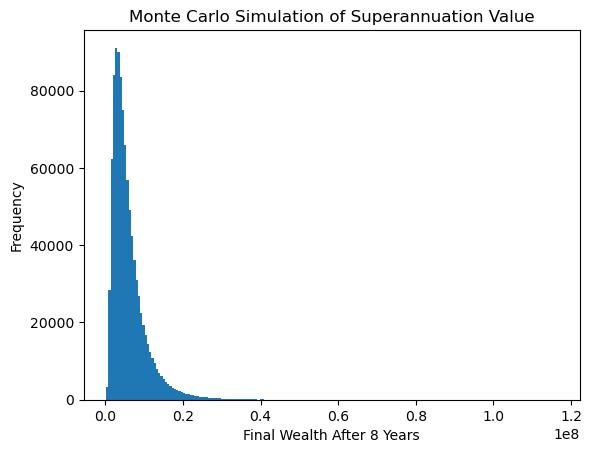

The median wealth in 10 years time is: 4741818.870184591 $
5% Value at Risk (Final Wealth): 1600535.5330786647


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# here we are making assumptions. We assume we are modelling a high risk portfolio based superannuation
years = 30
mu = 0.07
sigma = 0.15
initial = 250000

sims = 1000000

# simulate annual returns normally
normal_returns = np.random.normal(mu, sigma, (sims, years))
# simulating rare jumps in market through poisson distribution
lambda_poisson = 1
poisson_events = np.random.poisson(lambda_poisson, (sims, years))

# the size of the jump is simulated normally

jump_mu = 0.03           
jump_sigma = 0.015       
jump_dist = np.random.normal(jump_mu, jump_sigma, (sims, years))
jump_shocks = jump_dist * poisson_events

# this is simulating a somewhat bullish market and portfolio, assumable for superannuation purposes
prob_pos = 0.8
prob_neg = 0.2
negitive_mask = np.random.rand(sims, years) < prob_neg
positive_mask = np.random.rand(sims, years) < prob_pos

negative_shocks = -jump_shocks * negitive_mask
positive_shocks = jump_shocks * positive_mask
annual_returns = negative_shocks + positive_shocks + normal_returns

# compute wealth multiplicatively by simulating annual contributions
contribution = 20000
wealth = np.full(sims, initial, dtype=float)

for year in range(years):
    wealth += contribution 
    wealth *= (1 + annual_returns[:, year])

plt.hist(wealth, bins=200) 
plt.xlabel("Final Wealth After 8 Years") 
plt.ylabel("Frequency") 
plt.title("Monte Carlo Simulation of Superannuation Value") 
plt.show()

# for uncertainity and risk purposes, the VaR at 5% is calculated
var_5 = np.percentile(wealth, 5)
print("The median wealth in 10 years time is:",np.median(wealth),"$")
print("5% Value at Risk (Final Wealth):", var_5)

alpha: 0.39832493454908874
beta: 1.1286230943871938
residual mean: 1.189524669241239e-16
residual std: 1.1241634647916263
portfolio mean: 0.5446428571428571
market mean: 0.12964285714285712


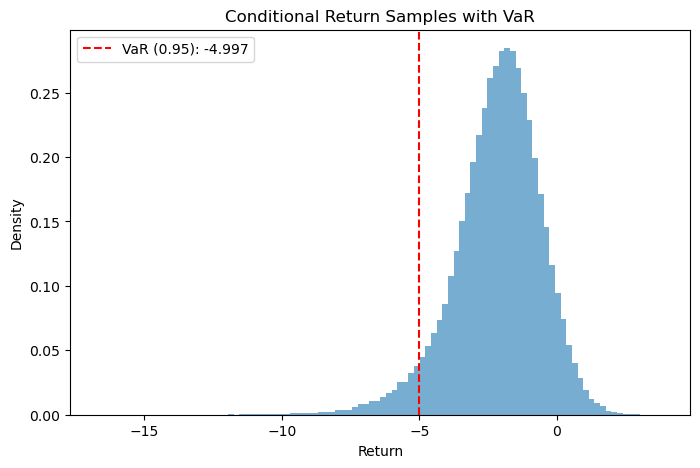

mean of conditional is: -2.166300685471291
median of conditional is: -2.0231936130514234
Worse 95% of returns are -4.996751711723384
Expected shortfall under VaR 0.95 is: -6.201350009870606
-16.66272003870101 3.819437027489181


In [15]:
import matplotlib.pyplot as plt
import numpy as np 

y = np.array([
    2.07, 2.91, -2.71, 0.99, -5.06, 3.52, 1.43, -2.32, -2.88, 4.11, 
    0.63, 1.33, 0.06, 3.35, -0.11, 1.82, -0.28, 1.06, 0.99, 0.70, 
    -1.04, 1.50, 1.74, 0.93, -0.34, 2.00, -0.96, -0.19
])

x = np.array([
    0.74, 0.83, -3.26, 0.49, -2.60, 1.78, 1.72, -2.09, -2.14, 1.56, 
    0.15, 1.12, 0.68, 3.78, -0.83, 1.16, -0.86, 1.63, -0.14, 0.65, 
    0.05, 0.87, -0.81, -0.84, -1.14, 0.77, -0.40, 0.76
])

X = np.column_stack([
    np.ones(len(x)),   # intercept
    x                  # market
])

XtX = X.T @ X
Xty = X.T @ y

theta = np.linalg.solve(XtX, Xty)

alpha = theta[0]
beta = theta[1]
y_hat = X @ theta


eps = y - y_hat

resid_mean = np.mean(eps)
resid_std = np.std(eps)

portfolio_mean = np.mean(y)
market_mean = np.mean(x)


print("alpha:", alpha)
print("beta:", beta)

print("residual mean:", resid_mean)
print("residual std:", resid_std)

print("portfolio mean:", portfolio_mean)
print("market mean:", market_mean)

cov_xy = np.mean((x - market_mean)*(y - portfolio_mean))

def Condition(X, Y, x_value):
    
    mu_x = np.mean(X)
    mu_y = np.mean(Y)

    var_x = np.var(X, ddof=1)
    var_y = np.var(Y, ddof=1)
    cov_xy = np.mean((x - market_mean)*(y - portfolio_mean))
    rho = cov_xy / (var_x**0.5 * var_y**0.5)

    cond_mean = mu_y + rho * (var_y**0.5 / var_x**0.5) * (x_value - mu_x)  
    cond_var = var_y * (1 - rho**2)

    return cond_mean, cond_var

cond_mean, cond_var = Condition(x, y, -2
)

samples = np.random.normal(cond_mean, cond_var**0.5, size=100000)

n = len(samples)

lambda_jump = 0.2   
jump_mean = -2.0    
jump_std = 1.0      

num_jumps = np.random.poisson(lambda_jump, n)

jumps = np.random.normal(jump_mean, jump_std, n) * num_jumps

samples_with_jumps = samples + jumps

def VaR(x, alpha=0.95):
    return np.percentile(x, (1-alpha) * 100)

def ES(x, alpha=0.95):
    var = VaR(x, alpha)  
    return x[x <= var].mean()

var_95 = VaR(samples_with_jumps, 0.95)
es_95 = ES(samples_with_jumps, 0.95)

plt.figure(figsize=(8,5))
plt.hist(samples_with_jumps, bins=100, density=True, alpha=0.6)

plt.axvline(var_95, color='red', linestyle='--', label=f'VaR (0.95): {var_95:.3f}')

plt.title("Conditional Return Samples with VaR")
plt.xlabel("Return")
plt.ylabel("Density")
plt.legend()

plt.show()

print("mean of conditional is:", np.mean(samples_with_jumps))
print("median of conditional is:", np.median(samples_with_jumps))
print("Worse 95% of returns are", var_95)
print("Expected shortfall under VaR 0.95 is:", es_95)
print(samples_with_jumps.min(), samples_with_jumps.max())

The Value at risk (0.95) under pareto severity is 14617070.42389186 The ES given VaR0.95 is 46909246.89615273
The Value at risk (0.95) under lognormal severity is 1499416.6276786916 The ES given VaR0.95 is 1777108.9765030001
The Value at risk (0.95) under distribution limiting is 1514154.1128822898 The ES given VaR0.95 is 1631261.8013768822
average loss under pareto severity is hence 8566890.457801148
average loss under lognormal severity is hence 1094266.1969198696
average loss using clt limitin is hence 1099458.2668244548
probability of loss under 800000 using clt limiting is 0.12350775594440083
probability of loss over 800000 using clt limiting is 0.8764922440555991


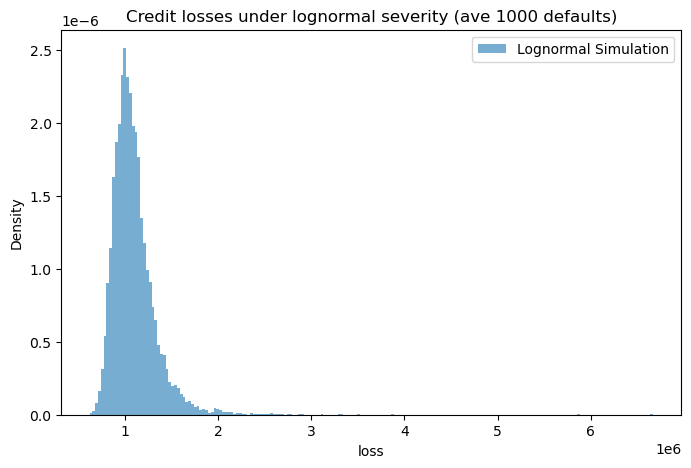

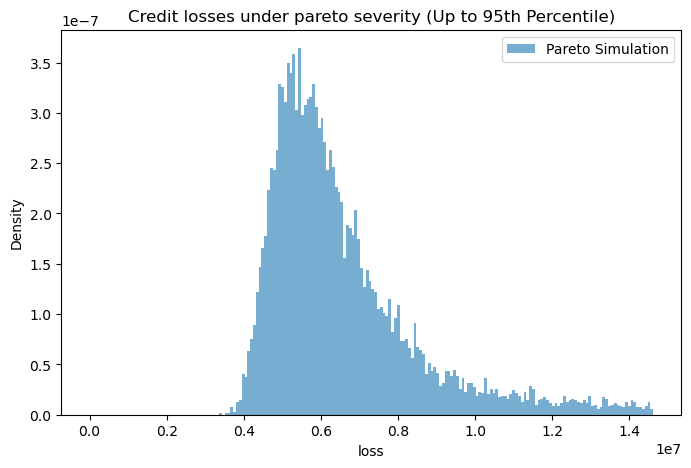

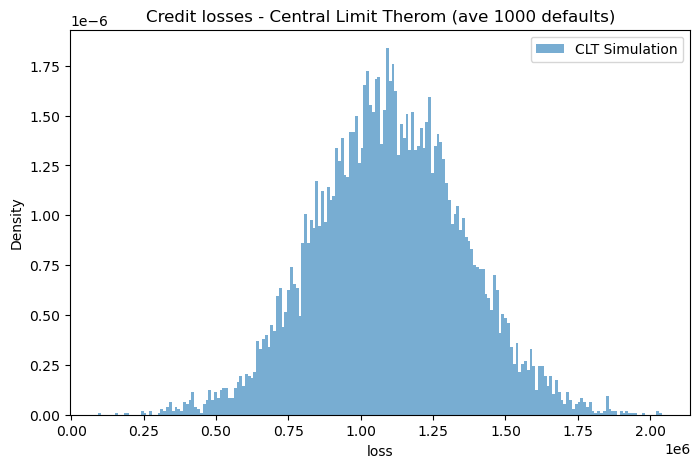

In [70]:
import numpy as np
from scipy.stats import pareto
from scipy.stats import norm

Montecarlo = 10000

# lognormal credit severity compounded with poisson process (this is discussed in writing)

def simulate_lognormal(K, mu = 5, sigma = 2):
    simulation_intensity = np.random.lognormal(mu, sigma, K)
    return simulation_intensity

def compound_lognormal(simulations, lamda_n):
    totals1 = []
    
    for _ in range(simulations):
        N = np.random.poisson(lamda_n)
        default_amt = simulate_lognormal(N)
        totals1.append(default_amt.sum())       

    return np.array(totals1)
        
    
lognormal_losses = compound_lognormal(Montecarlo, 1000)
E_lossesln = np.mean(lognormal_losses)

# pareto credit severity compounded with poisson process (uncover fat tail risks)

def simulate_pareto(B, gamma=1.1, xmin=1000):
    severity_pareto = pareto.rvs(gamma, scale=xmin, size=B)
    return severity_pareto

def compound_pareto(simulations, alpha_n):
    totals2 = []

    for _ in range(simulations):
        n_par = np.random.poisson(alpha_n)
        pareto_default = simulate_pareto(n_par)
        totals2.append(pareto_default.sum())

    return np.array(totals2)

pareto_losses = compound_pareto(Montecarlo, 1000)
E_lossespar = np.mean(pareto_losses)

def VaR(x, alpha = 0.95):
    return np.percentile(x, alpha * 100)

def ES(x, alpha = 0.95):
    var = VaR(x, alpha)
    return x[x >= var].mean()

# We can readily approximate losses using limiting distributions (central limit therom)
# the derivation below is fully examined in my mathematical writing

def CLT(lamda_n, ln_mu, ln_sd, simulations):
    
    e_ln = np.exp(ln_mu + (ln_sd)**2 / 2)
    var_y = np.exp((2 * ln_mu) + (2 * (ln_sd)**2))
    clt_limiting = np.random.normal(lamda_n * e_ln, np.sqrt(lamda_n * var_y), simulations)
    return np.array(clt_limiting)

clt_losses = CLT(1000, 5, 2, Montecarlo)
E_lossesclt = np.mean(clt_losses)

# risk metrics (VaR, ES)

clt_var95 = VaR(clt_losses, 0.95)
clt_es = ES(clt_losses, 0.95)
                  
pareto_var95 = VaR(pareto_losses, 0.95)
ln_var95 = VaR(lognormal_losses, 0.95)

pareto_es = ES(pareto_losses, 0.95)
ln_es = ES(lognormal_losses, 0.95)

# Pr(loss) calculations, this is discussed in my mathematical writing

def loss(monetary_value, ln_mu, ln_sd, lamda_n):
    
    e_norm = lamda_n * np.exp(ln_mu + (ln_sd)**2 / 2)
    sd_norm = np.sqrt(lamda_n * (np.exp((2 * ln_mu) + (2 * (ln_sd)**2))))
    cdf_val = (monetary_value - e_norm) / sd_norm
    loss_prob = norm.cdf(cdf_val)

    return loss_prob

value = 800000

loss_clt = loss(value, 5, 2, 1000)

# expressing results

print('The Value at risk (0.95) under pareto severity is', pareto_var95, 'The ES given VaR0.95 is', pareto_es)
print('The Value at risk (0.95) under lognormal severity is', ln_var95, 'The ES given VaR0.95 is', ln_es)
print('The Value at risk (0.95) under distribution limiting is', clt_var95, 'The ES given VaR0.95 is', clt_es)
print(f'average loss under pareto severity is hence {E_lossespar}')
print(f'average loss under lognormal severity is hence {E_lossesln}')
print(f'average loss using clt limitin is hence {E_lossesclt}')
print(f'probability of loss under {value} using clt limiting is {loss_clt}')
print(f'probability of loss over {value} using clt limiting is {1 - loss_clt}')

# graphing results

plt.figure(figsize=(8,5))
plt.hist(lognormal_losses, bins=200, density=True, alpha=0.6, label="Lognormal Simulation")
plt.title("Credit losses under lognormal severity (ave 1000 defaults)")
plt.xlabel("loss")
plt.ylabel("Density")
plt.legend()
plt.show()

pareto_cutoff = np.percentile(pareto_losses, 95)
plt.figure(figsize=(8,5))
plt.hist(pareto_losses, bins=200, range=(0, pareto_cutoff), density=True, alpha=0.6, label="Pareto Simulation")
plt.title("Credit losses under pareto severity (Up to 95th Percentile)")
plt.xlabel("loss")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(clt_losses, bins=200, density=True, alpha=0.6, label="CLT Simulation")
plt.title("Credit losses - Central Limit Therom (ave 1000 defaults)")
plt.xlabel("loss")
plt.ylabel("Density")
plt.legend()
plt.show()